In [130]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [131]:
df = pd.read_csv("/kaggle/input/iris/Iris.csv")

In [132]:
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [134]:
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [135]:
df["Species"] = df["Species"].map({ 'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2})

In [136]:
type (df.columns)

pandas.core.indexes.base.Index

In [137]:
df = df.drop("Id", axis = 1)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

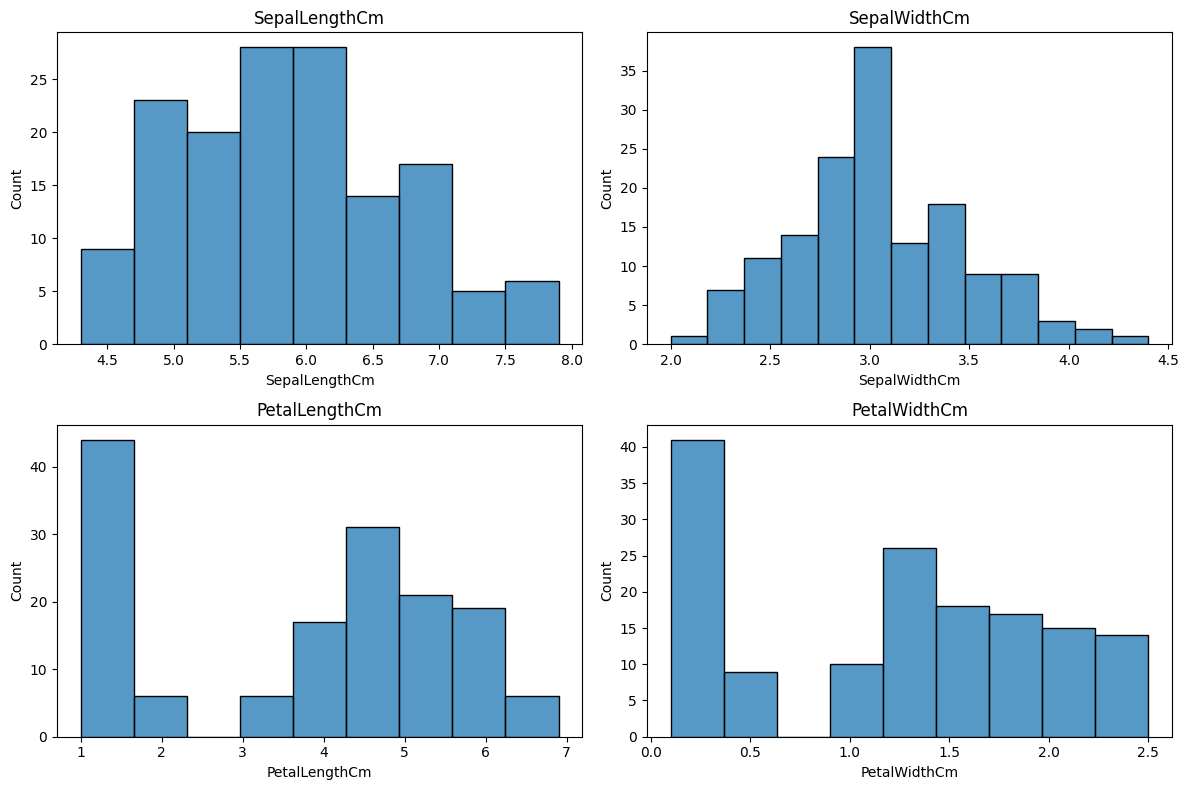

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns
col = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
plt.figure(figsize = (12,8))
for i , col  in enumerate (col, 1 ):
    plt.subplot (2,2 , i)
    sns.histplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()
    

## Normalisation

In [139]:
col = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler()
df[col] = pd.DataFrame(scaler_minmax.fit_transform(df[col]))





##  2.Use KNeighborsClassifier from sklearn.


In [140]:
from sklearn.model_selection import train_test_split 
X = df.drop('Species', axis = 1)
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=45) # stratify=y ensures equal proportion of classes in train/test splits


In [141]:
print (f"X_train.shape : {X_train.shape} , X_test.shape: {X_test.shape}  ,y_train.shape(): {y_train.shape} , y_test.shape: {y_test.shape} ")

X_train.shape : (75, 4) , X_test.shape: (75, 4)  ,y_train.shape(): (75,) , y_test.shape: (75,) 


In [142]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors=10)
knn_classifier.fit(X_train,y_train )
y_pred = knn_classifier.predict(X_test )


##  3.Evaluate model using accuracy, confusion matrix.
 

In [143]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy Score: 0.9600

Confusion Matrix:
[[29  0  0]
 [ 0 24  0]
 [ 0  3 19]]


## 4. Experimentign with differnrt k values 
Iteratign through  differnt k and recording their accuracy and loss 

In [144]:
test_accuracies = []
for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_test_pred = knn.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_accuracies.append(test_acc)
    print (f"{k} : {test_acc}")

1 : 0.9733333333333334
2 : 0.9733333333333334
3 : 0.9733333333333334
4 : 0.9733333333333334
5 : 0.9733333333333334
6 : 0.96
7 : 0.9733333333333334
8 : 0.96
9 : 0.96
10 : 0.96
11 : 0.96
12 : 0.96
13 : 0.9733333333333334
14 : 0.96
15 : 0.96
16 : 0.96
17 : 0.96
18 : 0.96
19 : 0.96
20 : 0.96


plot accruacies 

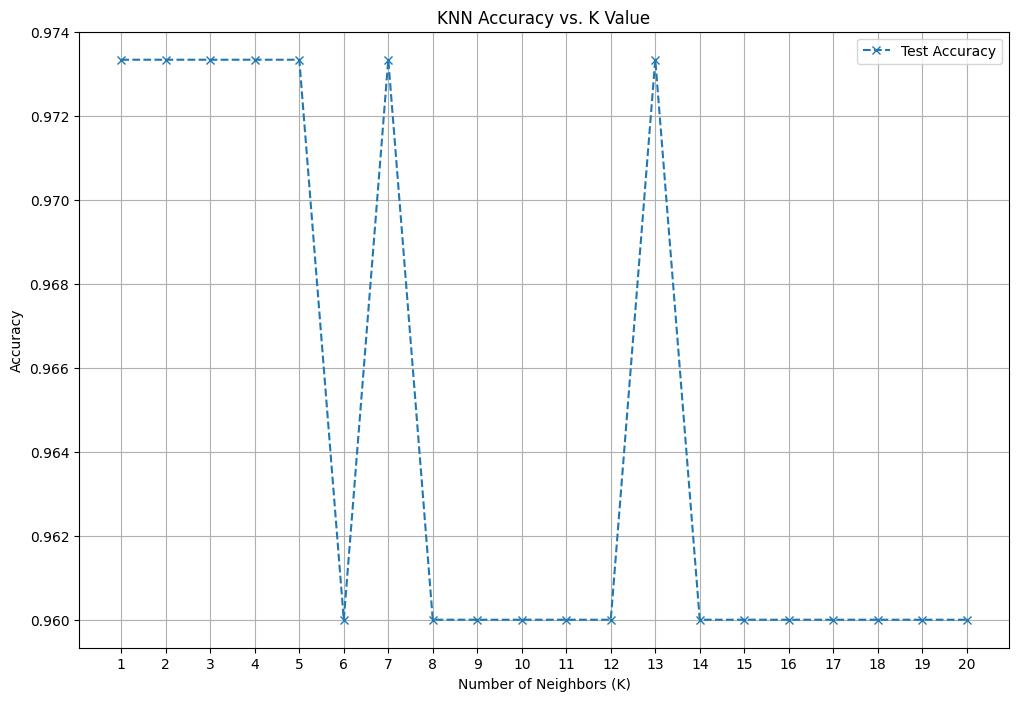

In [145]:
plt.figure(figsize=(12, 8 ))
plt.plot(range(1, 21), test_accuracies, marker='x', linestyle='--', label='Test Accuracy')
plt.title('KNN Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(range (1,21))
plt.grid(True)
plt.legend()
plt.show()

Small K (e.g., K=1): The model is highly flexible and can lead to overfitting (high train accuracy, potentially lower test accuracy due to sensitivity to noise). The decision boundaries are more complex.</br>
Large K: The model becomes smoother and more generalized. It averages more neighbors, which can reduce the impact of noise but might lead to underfitting (low train and test accuracy) if K is too large and masks local patterns </br>
Optimal K: Look for the K value where the test accuracy is highest and/or stable, and the gap between train and test accuracy is reasonable.

## 5. Visualize Decision Boundaries


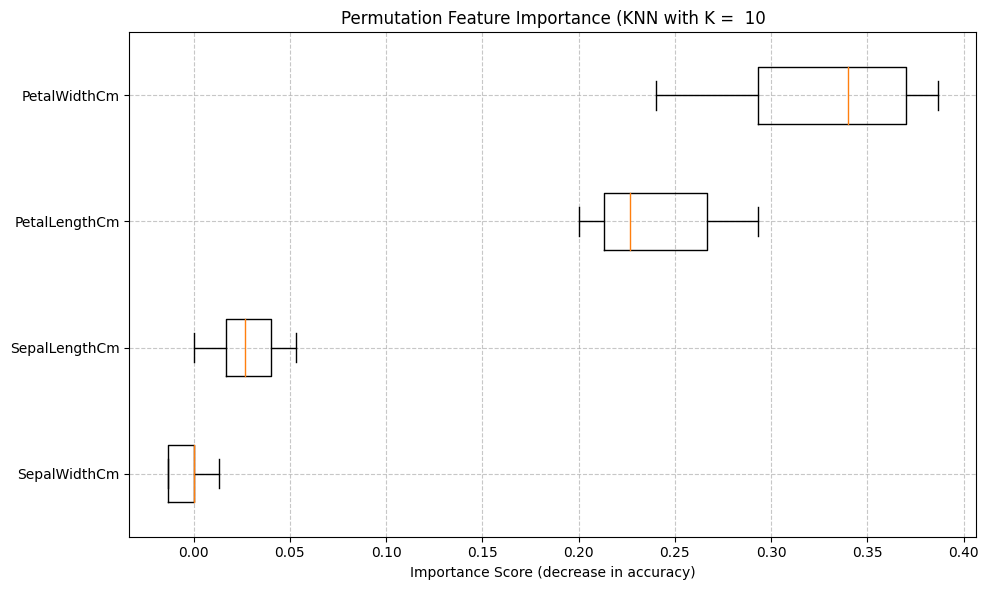

In [146]:
# FIndign , which feature has most importnce 
from sklearn.inspection import permutation_importance
results = permutation_importance(
    knn_classifier,          
    X_test,             
    y_test,             
    n_repeats=10,       
    random_state=42,    
    scoring='accuracy'
)
sorted_idx = results.importances_mean.argsort()
feature_importances = pd.DataFrame(
    results.importances[sorted_idx].T,
    columns=X.columns[sorted_idx]
)

plt.figure(figsize=(10, 6))
plt.boxplot(feature_importances, vert=False, labels=feature_importances.columns)
plt.title(f"Permutation Feature Importance (KNN with K =  10")
plt.xlabel("Importance Score (decrease in accuracy)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


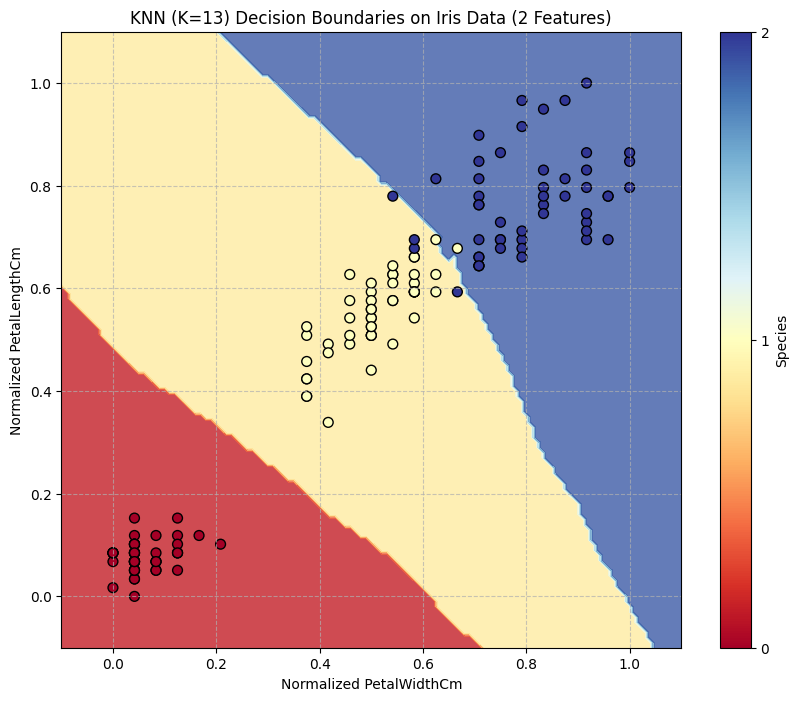

--- Decision Boundary Visualization Complete ---


In [151]:

feature1_name = 'PetalWidthCm'
feature2_name = 'PetalLengthCm'

# Extract only these two features and the target for visualization
X_plot = df[[feature1_name, feature2_name]]
y_plot = df['Species']

X_train_plot, X_test_plot, y_train_plot, y_test_plot = train_test_split(    X_plot, y_plot, test_size=0.3, random_state=42, stratify=y_plot)


knn_viz = KNeighborsClassifier(n_neighbors=13)
knn_viz.fit(X_plot, y_plot)

# --- Create a meshgrid to plot the decision boundaries ---
x_min, x_max = X_plot[feature1_name].min() - 0.1, X_plot[feature1_name].max() + 0.1
y_min, y_max = X_plot[feature2_name].min() - 0.1, X_plot[feature2_name].max() + 0.1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict class for each point in the meshgrid
Z = knn_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# --- Plotting ---
plt.figure(figsize=(10, 8))

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

# Plot actual data points
scatter = plt.scatter(X_plot[feature1_name], X_plot[feature2_name], c=y_plot,
                      edgecolor='k', s=50, cmap=plt.cm.RdYlBu)

# Add labels and title
plt.xlabel(f'Normalized {feature1_name}')
plt.ylabel(f'Normalized {feature2_name}')
plt.title(f'KNN (K=13) Decision Boundaries on Iris Data (2 Features)')
plt.colorbar(scatter, ticks=np.unique(y_plot), label='Species')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("--- Decision Boundary Visualization Complete ---")